# Allergenicity Data Curation

Pipeline overview:
- Step 1: process IEDB positives
- Step 2: process UniProt negatives
- Step 3: cluster, decontaminate, and split with MMseqs2

Important note:
- After positive deduplication, the positive table becomes protein-level. To preserve the requested column names, `epitope_start` and `epitope_end` are stored as semicolon-separated merged interval boundaries.

In [1]:
from __future__ import annotations

import io
import os
import re
import shutil
import subprocess
from dataclasses import dataclass
from pathlib import Path
import tempfile
from textwrap import wrap
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from Bio import Entrez, SeqIO
from sklearn.model_selection import GroupShuffleSplit

In [2]:
# Paths and runtime configuration.
PROJECT_ROOT = Path.cwd()
IEDB_CSV = PROJECT_ROOT / "data" / "t_cell_b_cell_MHC_II_epitopes.csv"
UNIPROT_TSV = PROJECT_ROOT / "data" / "uniprotkb_NOT_taxonomy_id_10239_NOT_tax_2026_04_08.tsv"
OUTPUT_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ENTREZ_EMAIL = "Jefferyyao315@gmail.com"  # TODO: replace with your email
Entrez.email = ENTREZ_EMAIL

UNIPROT_FASTA_URL = "https://rest.uniprot.org/uniprotkb/{accession}.fasta"
HTTP_TIMEOUT_SECONDS = 30
MMSEQS_TMP_DIRNAME = "tmp_mmseqs"
PLOT_FILENAME = "epitope_coverage_distribution.png"
EPITOPE_LENGTH_PLOT_FILENAME = "single_epitope_length_distribution.png"
MAX_SINGLE_EPITOPE_LENGTH = 50
MAX_SINGLE_EPITOPE_FRACTION = 0.25
MAX_PROTEIN_EPITOPE_COVERAGE = 0.75
FETCH_CACHE_CSV = OUTPUT_DIR / "iedb_sequence_fetch_cache.csv"
RAW_POSITIVE_EPITOPES_CSV = OUTPUT_DIR / "positive_epitopes_full.csv"
POSITIVE_EPITOPE_METADATA_CSV = OUTPUT_DIR / "positives_all_epitope_metadata.csv"
RANDOM_STATE = 13
MMSEQS_SAFE_ROOT = Path(tempfile.gettempdir()) / "xallergen2_mmseqs"
MMSEQS_SAFE_ROOT.mkdir(parents=True, exist_ok=True)
REUSE_FETCH_CACHE = True
REUSE_MMSEQS_RESULTS = True

# Optionally override these from the environment.
ENTREZ_EMAIL = os.environ.get("NCBI_EMAIL", ENTREZ_EMAIL)
Entrez.email = ENTREZ_EMAIL
ENTREZ_API_KEY = os.environ.get("NCBI_API_KEY", "")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IEDB_CSV exists: {IEDB_CSV.exists()}")
print(f"UNIPROT_TSV exists: {UNIPROT_TSV.exists()}")

PROJECT_ROOT: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0
IEDB_CSV exists: True
UNIPROT_TSV exists: True


## Helper Functions

In [3]:
@dataclass(frozen=True)
class FetchResult:
    accession: str
    sequence: str
    source: str


def normalize_column_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", str(name).strip().lower()).strip()


def build_column_lookup(columns: Iterable[str]) -> dict[str, str]:
    return {normalize_column_name(column): column for column in columns}


def require_column(df: pd.DataFrame, candidates: list[str]) -> str:
    lookup = build_column_lookup(df.columns)
    for candidate in candidates:
        normalized = normalize_column_name(candidate)
        if normalized in lookup:
            return lookup[normalized]
    raise ValueError(
        "Could not find a required column. Tried candidates: "
        f"{candidates}. Available columns: {list(df.columns)}"
    )


def print_step_summary(step_name: str, before: int, after: int) -> None:
    print(f"{step_name}: before={before}, after={after}")


def print_progress_bar(current: int, total: int, prefix: str = "", width: int = 40) -> None:
    total = max(total, 1)
    current = min(max(current, 0), total)
    filled = int(width * current / total)
    bar = "#" * filled + "-" * (width - filled)
    end = "\n" if current == total else "\r"
    print(f"{prefix}[{bar}] {current}/{total}", end=end, flush=True)


def load_sequence_cache(path: Path) -> dict[str, str]:
    if not path.exists():
        return {}
    cache_df = pd.read_csv(path)
    required_columns = {"accession", "sequence"}
    if not required_columns.issubset(cache_df.columns):
        return {}
    cache_df = cache_df.dropna(subset=["accession", "sequence"]).copy()
    cache_df["accession"] = cache_df["accession"].astype(str).str.strip()
    cache_df["sequence"] = cache_df["sequence"].astype(str).map(normalize_sequence)
    return dict(zip(cache_df["accession"], cache_df["sequence"]))


def save_sequence_cache(sequence_map: dict[str, str], path: Path) -> None:
    cache_df = pd.DataFrame(
        sorted(sequence_map.items()),
        columns=["accession", "sequence"],
    )
    cache_df.to_csv(path, index=False)


def extract_accession(value: object) -> str | None:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None

    text = str(value).strip()
    if not text:
        return None

    text = text.rstrip("/")
    patterns = [
        r"/uniprotkb/([A-Z0-9]+(?:-\d+)?)",
        r"/uniprot/([A-Z0-9]+(?:-\d+)?)",
        r"/protein/([A-Z0-9_.]+)",
        r"\b([OPQ][0-9][A-Z0-9]{3}[0-9](?:-\d+)?)\b",
        r"\b([A-NR-Z][0-9][A-Z0-9]{3}[0-9](?:-\d+)?)\b",
        r"\b([A-Z]{1,4}_[0-9]+(?:\.[0-9]+)?)\b",
        r"\b([A-Z]{3,6}[0-9]{2,}(?:\.[0-9]+)?)\b",
    ]
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            return match.group(1)
    return None


def normalize_sequence(seq: str) -> str:
    return re.sub(r"\s+", "", str(seq).strip()).upper()


def configure_entrez(email: str, api_key: str) -> None:
    Entrez.email = email or ENTREZ_EMAIL
    if api_key:
        Entrez.api_key = api_key


def fetch_uniprot_fasta(accession: str, session: requests.Session) -> str | None:
    url = UNIPROT_FASTA_URL.format(accession=accession)
    response = session.get(url, timeout=HTTP_TIMEOUT_SECONDS)
    if response.status_code == 404:
        return None
    response.raise_for_status()
    record = SeqIO.read(io.StringIO(response.text), "fasta")
    return normalize_sequence(str(record.seq))


def fetch_ncbi_fasta(accession: str) -> str | None:
    try:
        with Entrez.efetch(db="protein", id=accession, rettype="fasta", retmode="text") as handle:
            fasta_text = handle.read()
    except Exception:
        return None

    if not fasta_text:
        return None

    try:
        record = SeqIO.read(io.StringIO(fasta_text), "fasta")
    except Exception:
        return None
    return normalize_sequence(str(record.seq))


def fetch_sequence(accession: str, session: requests.Session) -> FetchResult | None:
    # Some IEDB source identifiers are not UniProt accessions, for example
    # PDB chain identifiers like 2EJN_A. UniProt can return HTTP 400 for
    # those, so any UniProt request failure falls through to NCBI.
    try:
        sequence = fetch_uniprot_fasta(accession, session)
        if sequence:
            return FetchResult(accession=accession, sequence=sequence, source="uniprot")
    except requests.RequestException:
        pass

    sequence = fetch_ncbi_fasta(accession)
    if sequence:
        return FetchResult(accession=accession, sequence=sequence, source="ncbi")

    return None


def merge_intervals(intervals: list[tuple[int, int]]) -> list[tuple[int, int]]:
    if not intervals:
        return []
    sorted_intervals = sorted(intervals, key=lambda pair: (pair[0], pair[1]))
    merged = [sorted_intervals[0]]
    for start, end in sorted_intervals[1:]:
        last_start, last_end = merged[-1]
        if start <= last_end + 1:
            merged[-1] = (last_start, max(last_end, end))
        else:
            merged.append((start, end))
    return merged


def ensure_column_exists(df: pd.DataFrame, column: str) -> None:
    if column not in df.columns:
        raise ValueError(f"Required column '{column}' not found. Available columns: {list(df.columns)}")


def write_fasta_from_df(df: pd.DataFrame, accession_col: str, sequence_col: str, path: Path) -> None:
    with path.open("w", encoding="utf-8") as handle:
        for row in df.itertuples(index=False):
            accession = getattr(row, accession_col)
            sequence = normalize_sequence(getattr(row, sequence_col))
            handle.write(f">{accession}\n")
            for chunk in wrap(sequence, 60):
                handle.write(f"{chunk}\n")


def require_mmseqs() -> str:
    env_path = os.environ.get("MMSEQS_BINARY", "").strip()
    candidate_paths = []
    if env_path:
        candidate_paths.append(Path(env_path).expanduser())

    candidate_paths.extend(
        [
            PROJECT_ROOT / "external" / "mmseqs" / "bin" / "mmseqs",
            PROJECT_ROOT / "external" / "mmseqs" / "mmseqs",
            PROJECT_ROOT / "mmseqs" / "bin" / "mmseqs",
            PROJECT_ROOT / "mmseqs" / "mmseqs",
        ]
    )

    mmseqs_path = shutil.which("mmseqs")
    if mmseqs_path:
        return mmseqs_path

    for candidate in candidate_paths:
        if candidate.exists() and os.access(candidate, os.X_OK):
            return str(candidate.resolve())

    searched = "\n".join(f"  - {candidate}" for candidate in candidate_paths)
    raise RuntimeError(
        "MMseqs2 executable 'mmseqs' was not found on PATH.\n"
        "You can set MMSEQS_BINARY to the executable path or place it in one of these common locations:\n"
        f"{searched}"
    )


def run_checked(cmd: list[str], cwd: Path) -> None:
    completed = subprocess.run(cmd, cwd=cwd, check=False)
    if completed.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {completed.returncode}: {' '.join(cmd)}")

def ensure_clean_dir(path: Path) -> Path:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def copy_fasta_to_safe_mmseqs_dir(source_path: Path, safe_dir: Path) -> Path:
    safe_dir.mkdir(parents=True, exist_ok=True)
    safe_path = safe_dir / source_path.name
    shutil.copy2(source_path, safe_path)
    return safe_path


def parse_mmseqs_cluster_tsv(path: Path) -> pd.DataFrame:
    clusters = pd.read_csv(path, sep="\t", header=None, names=["rep", "member"])
    if clusters.empty:
        raise ValueError(f"Cluster file is empty: {path}")
    return clusters


def read_fasta_accessions(path: Path) -> set[str]:
    accessions = set()
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            if line.startswith(">"):
                accessions.add(line[1:].strip().split()[0])
    return accessions


def assign_cluster_ids(cluster_df: pd.DataFrame) -> tuple[dict[str, str], int]:
    cluster_df = cluster_df.copy()
    cluster_df["cluster_id"] = cluster_df["rep"].astype(str)
    accession_to_cluster = dict(zip(cluster_df["member"].astype(str), cluster_df["cluster_id"].astype(str)))
    cluster_count = cluster_df["cluster_id"].nunique()
    return accession_to_cluster, cluster_count


def run_easy_cluster(fasta_path: Path, prefix_path: Path, tmp_dir: Path, mmseqs_exe: str, reuse_existing: bool = True) -> tuple[Path, pd.DataFrame, int]:
    cluster_tsv = prefix_path.parent / f"{prefix_path.name}_cluster.tsv"
    if reuse_existing and cluster_tsv.exists():
        cluster_df = parse_mmseqs_cluster_tsv(cluster_tsv)
        fasta_accessions = read_fasta_accessions(fasta_path)
        cluster_members = set(cluster_df["member"].astype(str))
        missing_members = sorted(fasta_accessions - cluster_members)
        extra_members = sorted(cluster_members - fasta_accessions)
        if not missing_members and not extra_members:
            _, cluster_count = assign_cluster_ids(cluster_df)
            print(f"Reusing existing MMseqs cluster file: {cluster_tsv}")
            return cluster_tsv, cluster_df, cluster_count

        print(
            "Existing MMseqs cluster file is stale for the current FASTA and will be rebuilt: "
            f"{cluster_tsv} | missing_members={len(missing_members)} | extra_members={len(extra_members)}"
        )

    safe_job_dir = ensure_clean_dir(MMSEQS_SAFE_ROOT / prefix_path.name)
    safe_fasta = copy_fasta_to_safe_mmseqs_dir(fasta_path, safe_job_dir)
    safe_prefix = safe_job_dir / prefix_path.name
    safe_tmp_dir = safe_job_dir / tmp_dir.name

    cmd = [
        mmseqs_exe,
        "easy-cluster",
        str(safe_fasta),
        str(safe_prefix),
        str(safe_tmp_dir),
        "--min-seq-id",
        "0.40",
        "-c",
        "0.80",
        "--cov-mode",
        "0",
    ]
    run_checked(cmd, cwd=safe_job_dir)

    safe_cluster_tsv = safe_job_dir / f"{prefix_path.name}_cluster.tsv"
    if not safe_cluster_tsv.exists():
        raise FileNotFoundError(f"Expected MMseqs cluster file not found: {safe_cluster_tsv}")
    shutil.copy2(safe_cluster_tsv, cluster_tsv)

    cluster_df = parse_mmseqs_cluster_tsv(cluster_tsv)
    _, cluster_count = assign_cluster_ids(cluster_df)
    return cluster_tsv, cluster_df, cluster_count


def keep_cluster_representatives(df: pd.DataFrame, accession_col: str, cluster_df: pd.DataFrame) -> pd.DataFrame:
    accession_to_cluster, _ = assign_cluster_ids(cluster_df)
    reps = set(cluster_df["rep"].astype(str))
    filtered = df[df[accession_col].astype(str).isin(reps)].copy()
    filtered["cluster_id"] = filtered[accession_col].astype(str).map(accession_to_cluster)
    return filtered.reset_index(drop=True)


def run_easy_search(query_fasta: Path, target_fasta: Path, hits_tsv: Path, tmp_dir: Path, mmseqs_exe: str, reuse_existing: bool = True) -> pd.DataFrame:
    if reuse_existing and hits_tsv.exists():
        print(f"Reusing existing MMseqs hits file: {hits_tsv}")
        try:
            hits = pd.read_csv(hits_tsv, sep="\t", header=None)
        except pd.errors.EmptyDataError:
            return pd.DataFrame(columns=["query", "target"])
        if hits.empty:
            return pd.DataFrame(columns=["query", "target"])
        hits = hits.iloc[:, :2].copy()
        hits.columns = ["query", "target"]
        return hits

    safe_job_dir = ensure_clean_dir(MMSEQS_SAFE_ROOT / "easy_search")
    safe_query = copy_fasta_to_safe_mmseqs_dir(query_fasta, safe_job_dir)
    safe_target = copy_fasta_to_safe_mmseqs_dir(target_fasta, safe_job_dir)
    safe_hits_tsv = safe_job_dir / hits_tsv.name
    safe_tmp_dir = safe_job_dir / tmp_dir.name

    cmd = [
        mmseqs_exe,
        "easy-search",
        str(safe_query),
        str(safe_target),
        str(safe_hits_tsv),
        str(safe_tmp_dir),
        "--min-seq-id",
        "0.30",
        "-c",
        "0.80",
        "--cov-mode",
        "0",
    ]
    run_checked(cmd, cwd=safe_job_dir)

    if not safe_hits_tsv.exists():
        raise FileNotFoundError(f"Expected MMseqs hits file not found: {safe_hits_tsv}")
    shutil.copy2(safe_hits_tsv, hits_tsv)

    try:
        hits = pd.read_csv(hits_tsv, sep="\t", header=None)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=["query", "target"])

    if hits.empty:
        return pd.DataFrame(columns=["query", "target"])

    hits = hits.iloc[:, :2].copy()
    hits.columns = ["query", "target"]
    return hits


def split_combined_by_group(
    positives: pd.DataFrame,
    negatives: pd.DataFrame,
    group_col: str,
    random_state: int,
    split_a_fraction: float = 0.8,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, float]]:
    if positives.empty and negatives.empty:
        return positives.copy(), positives.copy(), negatives.copy(), negatives.copy(), {}

    ensure_column_exists(positives, group_col)
    ensure_column_exists(negatives, group_col)

    positives_working = positives.copy()
    negatives_working = negatives.copy()
    positives_working["label"] = 1
    negatives_working["label"] = 0
    positives_working["split_group_id"] = "pos::" + positives_working[group_col].astype(str)
    negatives_working["split_group_id"] = "neg::" + negatives_working[group_col].astype(str)

    combined = pd.concat([positives_working, negatives_working], ignore_index=True)
    group_summary = (
        combined.groupby("split_group_id", sort=False)
        .agg(
            n_samples=("label", "size"),
            n_positives=("label", "sum"),
            n_negatives=("label", lambda values: int((1 - values).sum())),
        )
        .reset_index()
    )
    group_summary["priority"] = (
        group_summary[["n_samples", "n_positives", "n_negatives"]]
        .max(axis=1)
        .astype(float)
    )

    rng = np.random.default_rng(random_state)
    group_summary["shuffle_key"] = rng.random(len(group_summary))
    group_summary = group_summary.sort_values(
        ["priority", "n_samples", "shuffle_key"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    total_samples = int(group_summary["n_samples"].sum())
    total_positives = int(group_summary["n_positives"].sum())
    total_negatives = int(group_summary["n_negatives"].sum())
    target_a_samples = total_samples * split_a_fraction
    target_a_positives = total_positives * split_a_fraction
    target_a_negatives = total_negatives * split_a_fraction

    split_a_groups: list[str] = []
    split_b_groups: list[str] = []
    a_samples = 0
    a_positives = 0
    a_negatives = 0

    for row in group_summary.itertuples(index=False):
        candidate_a_samples = a_samples + int(row.n_samples)
        candidate_a_positives = a_positives + int(row.n_positives)
        candidate_a_negatives = a_negatives + int(row.n_negatives)

        score_if_a = (
            abs(candidate_a_samples - target_a_samples)
            + abs(candidate_a_positives - target_a_positives)
            + abs(candidate_a_negatives - target_a_negatives)
        )
        score_if_b = (
            abs(a_samples - target_a_samples)
            + abs(a_positives - target_a_positives)
            + abs(a_negatives - target_a_negatives)
        )

        if not split_a_groups:
            assign_to_a = True
        elif not split_b_groups:
            assign_to_a = False
        else:
            assign_to_a = score_if_a <= score_if_b

        if assign_to_a:
            split_a_groups.append(row.split_group_id)
            a_samples = candidate_a_samples
            a_positives = candidate_a_positives
            a_negatives = candidate_a_negatives
        else:
            split_b_groups.append(row.split_group_id)

    split_a_mask = combined["split_group_id"].isin(split_a_groups)
    split_a_combined = combined.loc[split_a_mask].copy().reset_index(drop=True)
    split_b_combined = combined.loc[~split_a_mask].copy().reset_index(drop=True)

    positives_split_a = split_a_combined.loc[split_a_combined["label"] == 1].copy().reset_index(drop=True)
    positives_split_b = split_b_combined.loc[split_b_combined["label"] == 1].copy().reset_index(drop=True)
    negatives_split_a = split_a_combined.loc[split_a_combined["label"] == 0].copy().reset_index(drop=True)
    negatives_split_b = split_b_combined.loc[split_b_combined["label"] == 0].copy().reset_index(drop=True)

    summary = {
        "split_a_fraction": split_a_fraction,
        "split_b_fraction": 1.0 - split_a_fraction,
        "split_a_samples": float(len(split_a_combined)),
        "split_b_samples": float(len(split_b_combined)),
        "split_a_positives": float(len(positives_split_a)),
        "split_b_positives": float(len(positives_split_b)),
        "split_a_negatives": float(len(negatives_split_a)),
        "split_b_negatives": float(len(negatives_split_b)),
        "split_a_positive_rate": float(len(positives_split_a) / max(len(split_a_combined), 1)),
        "split_b_positive_rate": float(len(positives_split_b) / max(len(split_b_combined), 1)),
        "split_a_groups": float(len(split_a_groups)),
        "split_b_groups": float(len(split_b_groups)),
    }

    columns_to_drop = ["label", "split_group_id"]
    positives_split_a = positives_split_a.drop(columns=columns_to_drop, errors="ignore")
    positives_split_b = positives_split_b.drop(columns=columns_to_drop, errors="ignore")
    negatives_split_a = negatives_split_a.drop(columns=columns_to_drop, errors="ignore")
    negatives_split_b = negatives_split_b.drop(columns=columns_to_drop, errors="ignore")

    return positives_split_a, positives_split_b, negatives_split_a, negatives_split_b, summary


def match_negatives_to_positive_lengths(positives: pd.DataFrame, negatives: pd.DataFrame, random_state: int) -> pd.DataFrame:
    if len(negatives) < len(positives):
        raise ValueError(
            "Not enough negative proteins remain to match the positive set at 1:1. "
            f"positives={len(positives)}, negatives={len(negatives)}"
        )

    rng = np.random.default_rng(random_state)
    positive_lengths = (
        positives["sequence"]
        .astype(str)
        .str.len()
        .sample(frac=1.0, random_state=random_state)
        .tolist()
    )

    working = negatives.copy()
    working["_sequence_length"] = working["sequence"].astype(str).str.len()
    available = (
        working[["_sequence_length"]]
        .reset_index()
        .sort_values(["_sequence_length", "index"], kind="mergesort")
        .reset_index(drop=True)
    )

    available_lengths = available["_sequence_length"].to_numpy()
    available_indices = available["index"].to_numpy()
    selected_indices: list[int] = []

    for target_length in positive_lengths:
        insert_pos = np.searchsorted(available_lengths, target_length)
        candidate_positions = []
        if insert_pos < len(available_lengths):
            candidate_positions.append(insert_pos)
        if insert_pos > 0:
            candidate_positions.append(insert_pos - 1)

        if not candidate_positions:
            raise RuntimeError("Negative length matching ran out of candidates unexpectedly.")

        best_position = min(
            candidate_positions,
            key=lambda pos: (abs(int(available_lengths[pos]) - int(target_length)), rng.random()),
        )
        selected_indices.append(int(available_indices[best_position]))
        available_lengths = np.delete(available_lengths, best_position)
        available_indices = np.delete(available_indices, best_position)

    matched = working.loc[selected_indices].copy().reset_index(drop=True)
    matched = matched.drop(columns=["_sequence_length"], errors="ignore")
    return matched


def filter_max_sequence_length(df: pd.DataFrame, max_length: int) -> pd.DataFrame:
    filtered = df[df["sequence"].astype(str).str.len() <= max_length].copy().reset_index(drop=True)
    return filtered


def delete_path_if_exists(path: Path) -> None:
    if path.is_dir():
        shutil.rmtree(path)
    elif path.exists():
        path.unlink()

## Step 1A: Load IEDB Positives and Fetch Full Protein Sequences

In [4]:
def load_iedb_epitopes(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    epitope_sequence_col = require_column(df, ["Epitope - Name", "epitope sequence", "epitope"])
    epitope_start_col = require_column(df, ["Epitope - Starting Position", "epitope start", "start position"])
    epitope_end_col = require_column(df, ["Epitope - Ending Position", "epitope end", "end position"])
    organism_col = require_column(df, ["Epitope - Source Organism", "organism name", "organism"])

    accession_source_cols = []
    for candidate in [
        "Epitope - Molecule Parent IRI",
        "Epitope - Source Molecule IRI",
        "Epitope - Molecule Parent",
        "Epitope - Source Molecule",
    ]:
        try:
            accession_source_cols.append(require_column(df, [candidate]))
        except ValueError:
            continue

    if not accession_source_cols:
        raise ValueError("Could not find any accession-bearing columns in the IEDB export.")

    working = df.copy()
    working["epitope_sequence"] = working[epitope_sequence_col].astype(str).map(normalize_sequence)
    working["epitope_start"] = pd.to_numeric(working[epitope_start_col], errors="coerce")
    working["epitope_end"] = pd.to_numeric(working[epitope_end_col], errors="coerce")
    working["organism"] = working[organism_col].fillna("").astype(str).str.strip()

    def row_accession(row: pd.Series) -> str | None:
        for column in accession_source_cols:
            accession = extract_accession(row[column])
            if accession:
                return accession
        return None

    working["accession"] = working.apply(row_accession, axis=1)
    working = working.dropna(subset=["accession", "epitope_start", "epitope_end"]).copy()
    working["accession"] = working["accession"].astype(str).str.strip()
    working["epitope_start"] = working["epitope_start"].astype(int)
    working["epitope_end"] = working["epitope_end"].astype(int)
    working = working.loc[working["epitope_start"] <= working["epitope_end"]].copy()

    return working[["accession", "organism", "epitope_sequence", "epitope_start", "epitope_end"]].reset_index(drop=True)


def load_cached_positive_epitope_table(path: Path, iedb_df: pd.DataFrame) -> pd.DataFrame | None:
    if not path.exists():
        return None

    cached = pd.read_csv(path)
    required_columns = {"accession", "sequence", "organism", "epitope_start", "epitope_end"}
    if not required_columns.issubset(cached.columns):
        return None

    current_accessions = set(iedb_df["accession"].dropna().astype(str))
    cached_accessions = set(cached["accession"].dropna().astype(str))
    if current_accessions != cached_accessions:
        return None

    cached["sequence"] = cached["sequence"].astype(str).map(normalize_sequence)
    return cached[["accession", "sequence", "organism", "epitope_start", "epitope_end"]].copy()


def build_positive_epitope_table(iedb_df: pd.DataFrame, entrez_email: str, entrez_api_key: str) -> pd.DataFrame:
    configure_entrez(entrez_email, entrez_api_key)
    cached = load_cached_positive_epitope_table(RAW_POSITIVE_EPITOPES_CSV, iedb_df)
    if cached is not None:
        print(f"Loaded previously fetched IEDB full protein sequences from {RAW_POSITIVE_EPITOPES_CSV.name}")
        return cached.reset_index(drop=True)

    unique_accessions = sorted(iedb_df["accession"].dropna().astype(str).unique())
    sequence_map: dict[str, str] = load_sequence_cache(FETCH_CACHE_CSV) if REUSE_FETCH_CACHE else {}
    sequence_map = {accession: sequence for accession, sequence in sequence_map.items() if accession in set(unique_accessions)}
    failed_accessions: list[str] = []
    missing_accessions = [accession for accession in unique_accessions if accession not in sequence_map]

    if sequence_map:
        print(f"Loaded {len(sequence_map):,} cached sequences from {FETCH_CACHE_CSV.name}")

    with requests.Session() as session:
        total_accessions = len(missing_accessions)
        print_progress_bar(0, total_accessions, prefix="Fetching uncached IEDB source protein sequences ")
        for index, accession in enumerate(missing_accessions, start=1):
            result = fetch_sequence(accession, session)
            if result is None:
                failed_accessions.append(accession)
            else:
                sequence_map[result.accession] = result.sequence
            if index % 25 == 0 or index == total_accessions:
                save_sequence_cache(sequence_map, FETCH_CACHE_CSV)
            print_progress_bar(index, total_accessions, prefix="Fetching uncached IEDB source protein sequences ")
    if missing_accessions and not FETCH_CACHE_CSV.exists():
        save_sequence_cache(sequence_map, FETCH_CACHE_CSV)

    positives = iedb_df.copy()
    positives["sequence"] = positives["accession"].map(sequence_map)
    positives = positives.dropna(subset=["sequence"]).copy()

    if failed_accessions:
        print(
            f"Warning: could not fetch sequences for {len(failed_accessions)} accessions. "
            "Rows using those accessions were dropped."
        )
        preview = ", ".join(failed_accessions[:10])
        if preview:
            suffix = " ..." if len(failed_accessions) > 10 else ""
            print(f"Unresolved accession examples: {preview}{suffix}")

    return positives[["accession", "sequence", "organism", "epitope_start", "epitope_end"]].reset_index(drop=True)

In [5]:
iedb_epitopes = load_iedb_epitopes(IEDB_CSV)
positive_epitopes = build_positive_epitope_table(iedb_epitopes, ENTREZ_EMAIL, ENTREZ_API_KEY)
positive_epitopes.to_csv(RAW_POSITIVE_EPITOPES_CSV, index=False)
print_step_summary("step_1a_build_positive_epitope_table", len(iedb_epitopes), len(positive_epitopes))
print(f"Saved raw fetched epitope table: {RAW_POSITIVE_EPITOPES_CSV}")
positive_epitopes.head()

Loaded previously fetched IEDB full protein sequences from positive_epitopes_full.csv
step_1a_build_positive_epitope_table: before=4221, after=4221
Saved raw fetched epitope table: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positive_epitopes_full.csv


,accession,sequence,organism,epitope_start,epitope_end
0,Q5RZZ3,MAYSAMTKLALVVALCMVVSVPIAQAITCGQVSSSLAPCIPYVRGG...,Prunus persica,92,101
1,Q40963,AAAAVPRRGPRGGPGRSYTADAGYAPATPAAAGAAAGKATTEEQKL...,Phleum pratense,35,61
2,Q40963,AAAAVPRRGPRGGPGRSYTADAGYAPATPAAAGAAAGKATTEEQKL...,Phleum pratense,35,67
3,Q9XF24,MAVQKYTVALFLAVALVAGPAASYAADAGYTPAAAATPATPAATPA...,Lolium perenne,251,270
4,Q40962,ADLGYGPATPAAPAAGYTPATPAAPAGADAAGKATTEEQKLIEKIN...,Phleum pratense,97,130


## Step 1B-1H: Filter Long Epitopes, Remove High-Coverage Proteins, Deduplicate, Filter Organisms, and Save `positives.csv`

In [6]:
def summarize_and_remove_proteins_requiring_clipping(epitope_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    working = epitope_df.copy()
    working["sequence_length"] = working["sequence"].astype(str).str.len()
    clipping_mask = (
        (working["sequence_length"] <= 0)
        | (working["epitope_start"].astype(int) < 1)
        | (working["epitope_end"].astype(int) > working["sequence_length"])
    )
    clipping_rows = working.loc[clipping_mask].copy().reset_index(drop=True)
    if clipping_rows.empty:
        print("rows that require clipping: 0")
        return working.drop(columns=["sequence_length"]), clipping_rows

    print(f"rows that require clipping: {len(clipping_rows)}")
    clipping_examples = clipping_rows[["accession", "epitope_start", "epitope_end", "sequence_length"]].copy()
    clipping_examples["clipped_result"] = clipping_examples.apply(
        lambda row: f"{max(1, int(row['epitope_start']))}-{min(int(row['sequence_length']), int(row['epitope_end']))}",
        axis=1,
    )
    print("So clipping is rare, but it is real.")
    print("Examples I found:")
    print(clipping_examples.head(10).to_string(index=False))

    proteins_to_remove = clipping_rows[["accession", "sequence"]].drop_duplicates()
    filtered = working.merge(
        proteins_to_remove.assign(_remove_protein=True),
        on=["accession", "sequence"],
        how="left",
    )
    filtered = filtered.loc[filtered["_remove_protein"].isna()].drop(columns=["_remove_protein", "sequence_length"])
    return filtered.reset_index(drop=True), clipping_rows


def summarize_positive_proteins(epitope_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    grouped = epitope_df.groupby(["accession", "sequence"], sort=False)
    for (accession, sequence), group in grouped:
        seq_len = len(sequence)
        intervals = [
            (int(start), int(end))
            for start, end in zip(group["epitope_start"].astype(int), group["epitope_end"].astype(int))
            if seq_len > 0 and int(start) <= int(end)
        ]

        merged = merge_intervals(intervals)
        if not merged:
            continue

        covered_residues = sum(end - start + 1 for start, end in merged)
        coverage = covered_residues / seq_len if seq_len else 0.0
        organism = (
            group["organism"].dropna().astype(str).map(str.strip).replace("", np.nan).dropna().iloc[0]
            if not group["organism"].dropna().empty
            else ""
        )

        records.append(
            {
                "accession": accession,
                "sequence": sequence,
                "organism": organism,
                "sequence_length": seq_len,
                "n_epitopes_after_relative_filter": int(len(intervals)),
                "epitope_start": ";".join(str(start) for start, _ in merged),
                "epitope_end": ";".join(str(end) for _, end in merged),
                "epitope_coverage": coverage,
            }
        )
    return pd.DataFrame.from_records(records)


def apply_relative_epitope_filters(
    epitope_df: pd.DataFrame,
    max_single_epitope_fraction: float = 0.25,
    max_protein_coverage: float = 0.75,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int | float]]:
    working = epitope_df.copy()
    working["sequence_length"] = working["sequence"].astype(str).str.len().astype(int)
    working["epitope_length"] = working["epitope_end"].astype(int) - working["epitope_start"].astype(int) + 1
    working["max_allowed_epitope_length"] = working["sequence_length"] * max_single_epitope_fraction

    overlong_mask = working["epitope_length"] > working["max_allowed_epitope_length"]
    filtered_epitopes = working.loc[~overlong_mask].copy().reset_index(drop=True)
    excluded_epitopes = working.loc[overlong_mask].copy().reset_index(drop=True)

    proteins_before_relative_filter = working[["accession", "sequence"]].drop_duplicates()
    protein_summary = summarize_positive_proteins(filtered_epitopes)
    if protein_summary.empty:
        protein_summary = pd.DataFrame(
            columns=[
                "accession",
                "sequence",
                "organism",
                "sequence_length",
                "n_epitopes_after_relative_filter",
                "epitope_start",
                "epitope_end",
                "epitope_coverage",
            ]
        )

    proteins_with_no_epitopes = proteins_before_relative_filter.merge(
        protein_summary[["accession", "sequence"]].drop_duplicates().assign(_has_kept_epitope=True),
        on=["accession", "sequence"],
        how="left",
    )
    proteins_with_no_epitopes = proteins_with_no_epitopes.loc[
        proteins_with_no_epitopes["_has_kept_epitope"].isna(),
        ["accession", "sequence"],
    ].reset_index(drop=True)

    high_coverage_mask = protein_summary["epitope_coverage"].astype(float) > max_protein_coverage
    proteins_excluded = protein_summary.loc[high_coverage_mask].copy().reset_index(drop=True)
    proteins_kept = protein_summary.loc[~high_coverage_mask].copy().reset_index(drop=True)

    proteins_kept_keys = proteins_kept[["accession", "sequence"]].drop_duplicates()
    filtered_epitopes = filtered_epitopes.merge(
        proteins_kept_keys.assign(_keep_protein=True),
        on=["accession", "sequence"],
        how="inner",
    ).drop(columns=["_keep_protein"])

    summary = {
        "max_single_epitope_fraction": max_single_epitope_fraction,
        "max_protein_coverage": max_protein_coverage,
        "epitopes_before": int(len(working)),
        "epitopes_excluded_over_quarter": int(len(excluded_epitopes)),
        "epitopes_after_quarter_filter": int(len(filtered_epitopes)),
        "proteins_before_relative_filter": int(len(proteins_before_relative_filter)),
        "proteins_excluded_all_epitopes_over_quarter": int(len(proteins_with_no_epitopes)),
        "proteins_before_coverage_filter": int(len(protein_summary)),
        "proteins_excluded_over_coverage": int(len(proteins_excluded)),
        "proteins_after_coverage_filter": int(len(proteins_kept)),
    }

    if not excluded_epitopes.empty:
        print(
            f"Excluded epitopes with length > {max_single_epitope_fraction:.2f} * sequence length: "
            f"{len(excluded_epitopes)} of {len(working)}"
        )
        print(
            excluded_epitopes[
                ["accession", "epitope_start", "epitope_end", "epitope_length", "sequence_length"]
            ].head(10).to_string(index=False)
        )
    else:
        print(f"Excluded epitopes with length > {max_single_epitope_fraction:.2f} * sequence length: 0")

    if not proteins_excluded.empty:
        print(
            f"Excluded proteins with coverage > {max_protein_coverage:.2f} after epitope filtering: "
            f"{len(proteins_excluded)} of {len(protein_summary)}"
        )
        print(
            proteins_excluded[
                ["accession", "sequence_length", "n_epitopes_after_relative_filter", "epitope_coverage"]
            ].head(10).to_string(index=False)
        )
    else:
        print(f"Excluded proteins with coverage > {max_protein_coverage:.2f} after epitope filtering: 0")

    print("Relative epitope filter summary:")
    print(f"  epitopes before filter: {summary['epitopes_before']}")
    print(f"  epitopes excluded (> 1/4 sequence): {summary['epitopes_excluded_over_quarter']}")
    print(f"  epitopes kept: {summary['epitopes_after_quarter_filter']}")
    print(f"  proteins before relative filter: {summary['proteins_before_relative_filter']}")
    print(
        f"  proteins with no epitopes left after quarter filter: "
        f"{summary['proteins_excluded_all_epitopes_over_quarter']}"
    )
    print(f"  proteins before coverage filter: {summary['proteins_before_coverage_filter']}")
    print(f"  proteins excluded (> 75% coverage): {summary['proteins_excluded_over_coverage']}")
    print(f"  proteins kept: {summary['proteins_after_coverage_filter']}")

    return filtered_epitopes.reset_index(drop=True), proteins_kept, summary


def build_positive_epitope_metadata(epitope_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    grouped = epitope_df.groupby(["accession", "sequence"], sort=False)
    for (accession, sequence), group in grouped:
        raw_intervals = [
            (int(start), int(end))
            for start, end in zip(group["epitope_start"].astype(int), group["epitope_end"].astype(int))
        ]
        if not raw_intervals:
            continue

        organism = (
            group["organism"].dropna().astype(str).map(str.strip).replace("", np.nan).dropna().iloc[0]
            if not group["organism"].dropna().empty
            else ""
        )

        sequence_length = len(sequence)
        epitope_lengths = [end - start + 1 for start, end in raw_intervals]
        max_allowed_length = sequence_length * MAX_SINGLE_EPITOPE_FRACTION
        kept_intervals = [
            (start, end)
            for start, end in raw_intervals
            if (end - start + 1) <= max_allowed_length
        ]
        records.append(
            {
                "accession": accession,
                "sequence": sequence,
                "organism": organism,
                "sequence_length": sequence_length,
                "n_epitopes_raw": len(raw_intervals),
                "n_epitopes_excluded_over_quarter": int(len(raw_intervals) - len(kept_intervals)),
                "n_epitopes_kept_after_quarter_filter": int(len(kept_intervals)),
                "all_epitope_intervals_raw": "|".join(f"{start}-{end}" for start, end in raw_intervals),
                "epitope_lengths_raw": "|".join(str(length) for length in epitope_lengths),
                "all_epitope_intervals_kept_after_quarter_filter": "|".join(
                    f"{start}-{end}" for start, end in kept_intervals
                ),
            }
        )
    return pd.DataFrame.from_records(records)


def plot_and_filter_single_epitopes_by_length(
    epitope_df: pd.DataFrame,
    plot_path: Path,
    max_length: int = 50,
) -> pd.DataFrame:
    working = epitope_df.copy()
    working["epitope_length"] = working["epitope_end"].astype(int) - working["epitope_start"].astype(int) + 1
    filtered_df = working.loc[working["epitope_length"] <= max_length].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    max_observed = int(max(working["epitope_length"].max(), max_length))
    bins = np.arange(1, max_observed + 2) - 0.5
    ax.hist(
        working["epitope_length"].astype(int),
        bins=bins,
        alpha=0.55,
        color="#2c7fb8",
        edgecolor="black",
        label="Before filtering",
    )
    ax.hist(
        filtered_df["epitope_length"].astype(int),
        bins=bins,
        alpha=0.55,
        color="#f28e2b",
        edgecolor="black",
        label="After filtering",
    )
    ax.axvline(max_length, color="crimson", linestyle="--", linewidth=2, label=f"Max allowed length = {max_length}")
    ax.set_xlabel("Single-epitope length (aa)")
    ax.set_ylabel("Epitope count")
    ax.set_title("Single-Epitope Length Distribution Before and After Filtering")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_path, dpi=200)
    plt.show()
    plt.close(fig)
    return filtered_df.drop(columns=["epitope_length"])


def remove_identical_sequences(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop_duplicates(subset=["sequence"], keep="first").reset_index(drop=True)


def remove_forbidden_organisms(df: pd.DataFrame) -> pd.DataFrame:
    organism_lower = df["organism"].fillna("").astype(str).str.lower()
    keep_mask = ~organism_lower.str.contains("virus", na=False) & ~organism_lower.str.contains("homo sapiens", na=False)
    return df.loc[keep_mask].reset_index(drop=True)


def plot_epitope_coverage_distribution(df: pd.DataFrame, plot_path: Path) -> pd.DataFrame:
    fig, ax = plt.subplots(figsize=(9, 5))
    bins = np.linspace(0, 1, 31)
    ax.hist(
        df["epitope_coverage"].astype(float),
        bins=bins,
        alpha=0.75,
        color="#2c7fb8",
        edgecolor="black",
    )
    ax.set_xlabel("Epitope coverage fraction")
    ax.set_ylabel("Protein count")
    ax.set_title("Epitope Coverage Distribution")
    ax.set_xlim(0, 1)
    fig.tight_layout()
    fig.savefig(plot_path, dpi=200)
    plt.show()
    plt.close(fig)
    return df.reset_index(drop=True)


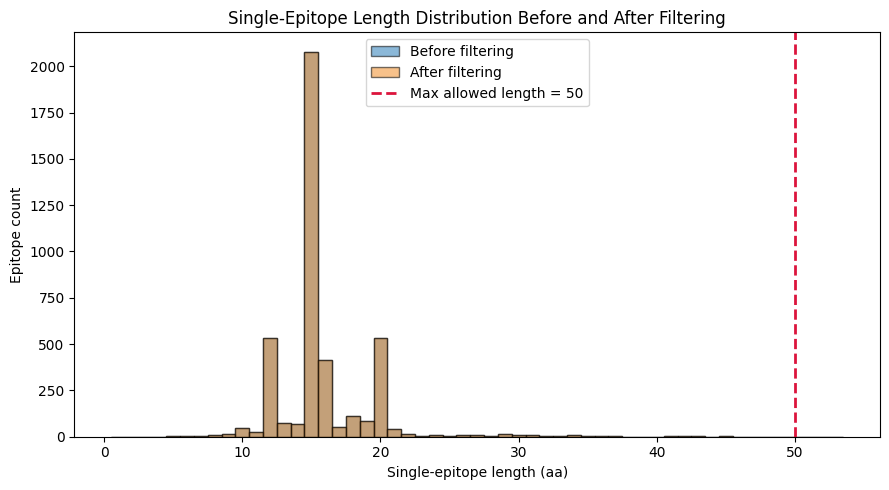

step_1b_filter_single_epitopes_over_50aa: before=4221, after=4220
rows that require clipping: 16
So clipping is rare, but it is real.
Examples I found:
 accession  epitope_start  epitope_end  sequence_length clipped_result
A0A445BYI5            148          165              160        148-160
A0A445BYI5            161          179              160        161-160
A0A445BYI5            152          170              160        152-160
A0A445BYI5            156          175              160        156-160
A0ABI7XLG5             78           92               88          78-88
    Q7M1X8            181          195               34         181-34
    Q7M1X8            221          240               34         221-34
A0A140KPS4           2371         2385             2321      2371-2321
    Q2L7A6           1182         1196              515       1182-515
A0A140KPS3            472          486              193        472-193
step_1c_remove_proteins_requiring_clipping: before=4220, after=4047

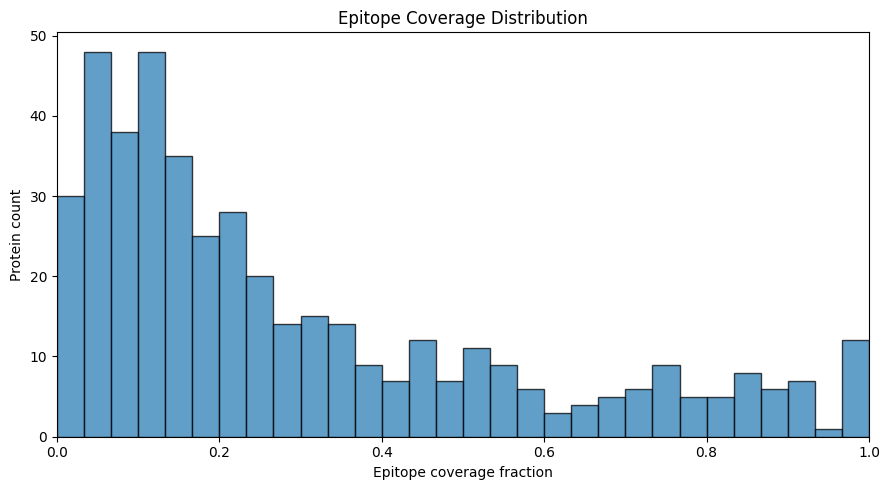

step_1f_keep_all_coverage_levels: before=447, after=447
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/single_epitope_length_distribution.png
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positives.csv
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positives_all_epitope_metadata.csv


,accession,sequence,organism,epitope_start,epitope_end,epitope_coverage
0,Q5RZZ3,MAYSAMTKLALVVALCMVVSVPIAQAITCGQVSSSLAPCIPYVRGG...,Prunus persica,1,117,1.000000
1,Q40963,AAAAVPRRGPRGGPGRSYTADAGYAPATPAAAGAAAGKATTEEQKL...,Phleum pratense,35;115;152;182;197,88;142;169;193;240,0.549296
2,Q9XF24,MAVQKYTVALFLAVALVAGPAASYAADAGYTPAAAATPATPAATPA...,Lolium perenne,62;125;170,117;162;270,0.647841
3,Q40962,ADLGYGPATPAAPAAGYTPATPAAPAGADAAGKATTEEQKLIEKIN...,Phleum pratense,46;79;161;199;239,64;139;186;219;258,0.513986
4,P22286,MAVQKYTVALFLVALVVGPAASYAADLSYGAPATPAAPAAGYTPAA...,Poa pratensis,41;81;161,70;150;290,0.749186


In [7]:
positive_epitopes_valid = plot_and_filter_single_epitopes_by_length(
    positive_epitopes,
    OUTPUT_DIR / EPITOPE_LENGTH_PLOT_FILENAME,
    max_length=MAX_SINGLE_EPITOPE_LENGTH,
)
print_step_summary("step_1b_filter_single_epitopes_over_50aa", len(positive_epitopes), len(positive_epitopes_valid))

positive_epitopes_in_bounds, clipping_rows = summarize_and_remove_proteins_requiring_clipping(positive_epitopes_valid)
print_step_summary("step_1c_remove_proteins_requiring_clipping", len(positive_epitopes_valid), len(positive_epitopes_in_bounds))

positive_epitopes_relative_filtered, coverage_filtered, relative_filter_summary = apply_relative_epitope_filters(
    positive_epitopes_in_bounds,
    max_single_epitope_fraction=MAX_SINGLE_EPITOPE_FRACTION,
    max_protein_coverage=MAX_PROTEIN_EPITOPE_COVERAGE,
)
print_step_summary(
    "step_1d_filter_single_epitopes_over_quarter_sequence",
    len(positive_epitopes_in_bounds),
    len(positive_epitopes_relative_filtered),
)
print_step_summary(
    "step_1e_remove_proteins_over_75pct_coverage",
    relative_filter_summary["proteins_before_coverage_filter"],
    relative_filter_summary["proteins_after_coverage_filter"],
)

deduplicated = remove_identical_sequences(coverage_filtered)
print_step_summary("step_1f_deduplicate_sequences", len(coverage_filtered), len(deduplicated))

organism_filtered = remove_forbidden_organisms(deduplicated)
print_step_summary("step_1g_remove_viral_and_human", len(deduplicated), len(organism_filtered))

positives = plot_epitope_coverage_distribution(organism_filtered, OUTPUT_DIR / PLOT_FILENAME)
print_step_summary("step_1h_finalize_positive_proteins", len(organism_filtered), len(positives))

positives_csv = OUTPUT_DIR / "positives.csv"
positives.to_csv(
    positives_csv,
    index=False,
    columns=["accession", "sequence", "organism", "epitope_start", "epitope_end", "epitope_coverage"],
)

positive_epitope_metadata = build_positive_epitope_metadata(positive_epitopes_in_bounds)
positive_epitope_metadata = positives.merge(
    positive_epitope_metadata,
    on=["accession", "sequence", "organism"],
    how="left",
)
positive_epitope_metadata["single_epitope_fraction_threshold"] = MAX_SINGLE_EPITOPE_FRACTION
positive_epitope_metadata["protein_coverage_threshold"] = MAX_PROTEIN_EPITOPE_COVERAGE
positive_epitope_metadata["protein_kept_after_coverage_filter"] = True
positive_epitope_metadata.to_csv(POSITIVE_EPITOPE_METADATA_CSV, index=False)

print(f"Saved: {OUTPUT_DIR / EPITOPE_LENGTH_PLOT_FILENAME}")
print(f"Saved: {positives_csv}")
print(f"Saved: {POSITIVE_EPITOPE_METADATA_CSV}")
positives.head()

## Step 2: Standardize UniProt Negatives and Save `negatives.csv`

In [8]:
def load_and_standardize_negatives(path: Path) -> pd.DataFrame:
    negatives = pd.read_csv(path, sep="\t")
    negatives.columns = [str(column).strip().lower() for column in negatives.columns]
    return negatives


negatives = load_and_standardize_negatives(UNIPROT_TSV)
negatives_csv = OUTPUT_DIR / "negatives.csv"
negatives.to_csv(negatives_csv, index=False)
print_step_summary("step_2a_standardize_negative_headers", len(negatives), len(negatives))
print(f"Saved: {negatives_csv}")
negatives.head()

step_2a_standardize_negative_headers: before=11139, after=11139
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/negatives.csv


,entry,reviewed,entry name,protein names,gene names,organism,length,sequence
0,A0A009IHW8,reviewed,ABTIR_ACIB9,2' cyclic ADP-D-ribose synthase AbTIR (2'cADPR...,J512_3302,Acinetobacter baumannii (strain 1295743),269,MSLEQKKGADIISKILQIQNSIGKTTSPSTLKTKLSEISRKEQENA...
1,A0A023I7E1,reviewed,ENG1_RHIMI,"Glucan endo-1,3-beta-D-glucosidase 1 (Endo-1,3...",ENG1 LAM81A,Rhizomucor miehei,796,MRFQVIVAAATITMITSYIPGVASQSTSDGDDLFVPVSNFDPKSIF...
2,A0A024SC78,reviewed,CUTI1_HYPJR,Cutinase (EC 3.1.1.74),M419DRAFT_76732,Hypocrea jecorina (strain ATCC 56765 / BCRC 32...,248,MRSLAILTTLLAGHAFAYPKPAPQSVNRRDWPSINEFLSELAKVMP...
3,A0A059TC02,reviewed,CCR1_PETHY,Cinnamoyl-CoA reductase 1 (Ph-CCR1) (EC 1.2.1....,CCR1,Petunia hybrida (Petunia),333,MRSVSGQVVCVTGAGGFIASWLVKILLEKGYTVRGTVRNPDDPKNG...
4,A0A061ACU2,reviewed,PIEZ1_CAEEL,Piezo-type mechanosensitive ion channel compon...,pezo-1 C10C5.1,Caenorhabditis elegans,2442,MTVPPLLKSCVVKLLLPAALLAAAIIRPSFLSIGYVLLALVSAVLP...


In [9]:
high_coverage_proteins = (
    positives.loc[positives["epitope_coverage"] > MAX_PROTEIN_EPITOPE_COVERAGE]
    .sort_values("epitope_coverage", ascending=False)
    .reset_index(drop=True)
)

print(
    f"Proteins with epitope_coverage > {MAX_PROTEIN_EPITOPE_COVERAGE:.2f} after filtering "
    f"(should be 0): {len(high_coverage_proteins)}"
)
high_coverage_proteins


Proteins with epitope_coverage > 0.6 (informational only): 70


,accession,sequence,organism,epitope_start,epitope_end,epitope_coverage
0,Q5RZZ3,MAYSAMTKLALVVALCMVVSVPIAQAITCGQVSSSLAPCIPYVRGG...,Prunus persica,1,117,1.000000
1,P18632,MDSPCLVALLVFSFVIGSCFSDNPIDSCWRGDSNWAQNRMKLADCA...,Cryptomeria japonica,1,374,1.000000
2,O18598,MAPSYKLTYCPVKALGEPIRFLLSYGEKDFEDYRFQEGDWPNLKPS...,Blattella germanica,1,204,1.000000
3,P02754,MKCLLLALALTCGAQALIVTQTMKGLDIQKVAGTWYSLAMAASDIS...,Bos taurus,1,178,1.000000
4,P38948,MGVFNYEAETPSVIPAARLFKAFILDGDKLLPKVAPEAVSSVENIE...,Alnus glutinosa,2,160,0.993750
...,...,...,...,...,...,...
65,Q9XF24,MAVQKYTVALFLAVALVAGPAASYAADAGYTPAAAATPATPAATPA...,Lolium perenne,62;125;170,117;162;270,0.647841
66,P49372,MGVQTHVLELTSSVSAEKIFQGFVIDVDTVLPKAAPGAYKSVEIKG...,Apium graveolens,2;29;89;110,25;40;106;154,0.642857
67,P67875,MVAIKNLFLLAATAVSVLAAPSPLDARATWTCINQQLNPKTNKWED...,Aspergillus fumigatus,6;28;73;118,20;47;107;160,0.642045
68,O96523,SRNLQDDLQDFLALIPVDQIIAIATDYLANDAEVQAAVAYLQSDEF...,Blattella germanica,6;76;120,70;114;134,0.632979


## Step 4A-4C: Write FASTA, Cluster Each Set, and Remove Negative Hits to Positives

In [10]:
MAX_CLUSTER_SEQUENCE_LENGTH = 1022

mmseqs_exe = require_mmseqs()
ensure_column_exists(positives, "accession")
ensure_column_exists(positives, "sequence")
ensure_column_exists(negatives, "entry")
ensure_column_exists(negatives, "sequence")

positives_before_length_filter = len(positives)
negatives_before_length_filter = len(negatives)
positives = filter_max_sequence_length(positives, MAX_CLUSTER_SEQUENCE_LENGTH)
negatives = filter_max_sequence_length(negatives, MAX_CLUSTER_SEQUENCE_LENGTH)
print_step_summary("step_4a_filter_max_length_1022_positives", positives_before_length_filter, len(positives))
print_step_summary("step_4a_filter_max_length_1022_negatives", negatives_before_length_filter, len(negatives))

positives_fasta = OUTPUT_DIR / "positives.fasta"
negatives_fasta = OUTPUT_DIR / "negatives.fasta"
negatives_nr_fasta = OUTPUT_DIR / "negatives_nr.fasta"
tmp_dir = OUTPUT_DIR / MMSEQS_TMP_DIRNAME

write_fasta_from_df(positives, "accession", "sequence", positives_fasta)
write_fasta_from_df(negatives, "entry", "sequence", negatives_fasta)
print(f"Saved: {positives_fasta}")
print(f"Saved: {negatives_fasta}")

step_4a_filter_max_length_1022_positives: before=447, after=430
step_4a_filter_max_length_1022_negatives: before=11139, after=10158
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positives.fasta
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/negatives.fasta


In [11]:
positives_prefix = OUTPUT_DIR / "positives_clusters"
negatives_prefix = OUTPUT_DIR / "negatives_clusters"

positives_before = len(positives)
_, positives_cluster_df, positives_cluster_count = run_easy_cluster(
    positives_fasta,
    positives_prefix,
    tmp_dir,
    mmseqs_exe,
    reuse_existing=REUSE_MMSEQS_RESULTS,
)
positive_accession_to_cluster, _ = assign_cluster_ids(positives_cluster_df)
positives_for_split = positives.copy()
positives_for_split["cluster_id"] = positives_for_split["accession"].astype(str).map(positive_accession_to_cluster)
missing_positive_cluster_ids = positives_for_split[positives_for_split["cluster_id"].isna()]["accession"].astype(str).tolist()
if missing_positive_cluster_ids:
    preview = missing_positive_cluster_ids[:10]
    raise ValueError(
        "Missing MMseqs cluster_id for retained positive accessions: "
        f"count={len(missing_positive_cluster_ids)}, examples={preview}"
    )
print_step_summary("step_4b_positive_cluster_assignment", positives_before, len(positives_for_split))
print(
    "step_4b_positive_cluster_assignment: "
    f"retained_positives_before_clustering={positives_before}, "
    f"positive_clusters={positives_cluster_count}, "
    f"retained_positives_after_cluster_assignment={len(positives_for_split)}"
)
positives_for_split.head()

Existing MMseqs cluster file is stale for the current FASTA and will be rebuilt: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positives_clusters_cluster.tsv | missing_members=0 | extra_members=6
Create directory /var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/xallergen2_mmseqs/positives_clusters/tmp_mmseqs
easy-cluster /var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/xallergen2_mmseqs/positives_clusters/positives.fasta /var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/xallergen2_mmseqs/positives_clusters/positives_clusters /var/folders/c0/44p3b4xx4v956042lj_vp7z80000gn/T/xallergen2_mmseqs/positives_clusters/tmp_mmseqs --min-seq-id 0.40 -c 0.80 --cov-mode 0 

MMseqs Version:                     	18-8cc5c
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        

,accession,sequence,organism,epitope_start,epitope_end,epitope_coverage,cluster_id
0,Q5RZZ3,MAYSAMTKLALVVALCMVVSVPIAQAITCGQVSSSLAPCIPYVRGG...,Prunus persica,1,117,1.000000,Q9ATH2
1,Q40963,AAAAVPRRGPRGGPGRSYTADAGYAPATPAAAGAAAGKATTEEQKL...,Phleum pratense,35;115;152;182;197,88;142;169;193;240,0.549296,O81341
2,Q9XF24,MAVQKYTVALFLAVALVAGPAASYAADAGYTPAAAATPATPAATPA...,Lolium perenne,62;125;170,117;162;270,0.647841,O81341
3,Q40962,ADLGYGPATPAAPAAGYTPATPAAPAGADAAGKATTEEQKLIEKIN...,Phleum pratense,46;79;161;199;239,64;139;186;219;258,0.513986,O81341
4,P22286,MAVQKYTVALFLVALVVGPAASYAADLSYGAPATPAAPAAGYTPAA...,Poa pratensis,41;81;161,70;150;290,0.749186,O81341


In [12]:
negatives_before = len(negatives)
_, negatives_cluster_df, negatives_cluster_count = run_easy_cluster(
    negatives_fasta,
    negatives_prefix,
    tmp_dir,
    mmseqs_exe,
    reuse_existing=REUSE_MMSEQS_RESULTS,
)
negatives_nr = keep_cluster_representatives(negatives, "entry", negatives_cluster_df)
write_fasta_from_df(negatives_nr, "entry", "sequence", negatives_nr_fasta)
print_step_summary("step_4b_negative_intra_set_nr", negatives_before, len(negatives_nr))
print(f"step_4b_negative_intra_set_nr: clusters={negatives_cluster_count}")
negatives_nr.head()

Reusing existing MMseqs cluster file: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/negatives_clusters_cluster.tsv
step_4b_negative_intra_set_nr: before=10158, after=7582
step_4b_negative_intra_set_nr: clusters=7582


,entry,reviewed,entry name,protein names,gene names,organism,length,sequence,cluster_id
0,A0A023I7E1,reviewed,ENG1_RHIMI,"Glucan endo-1,3-beta-D-glucosidase 1 (Endo-1,3...",ENG1 LAM81A,Rhizomucor miehei,796,MRFQVIVAAATITMITSYIPGVASQSTSDGDDLFVPVSNFDPKSIF...,A0A023I7E1
1,A0A024SC78,reviewed,CUTI1_HYPJR,Cutinase (EC 3.1.1.74),M419DRAFT_76732,Hypocrea jecorina (strain ATCC 56765 / BCRC 32...,248,MRSLAILTTLLAGHAFAYPKPAPQSVNRRDWPSINEFLSELAKVMP...,A0A024SC78
2,A0A068B6Q6,reviewed,CA18_CONBE,Conotoxin Bt1.8,NaN,Conus betulinus (Beech cone),37,PDGRNAAAKAFDLITPTVRKGCCSNPACILNNPNQCG,A0A068B6Q6
3,A0A075BSX9,reviewed,HLNO_SHIS7,(S)-6-hydroxynicotine oxidase ((S)-6HN oxidase...,nctB shn_30305,Shinella sp. (strain HZN7),437,MTEKIYDAIVVGAGFSGLVAARELSAQGRSVLIIEARHRLGGRTHV...,A0A075BSX9
4,A0A075TRK9,reviewed,PATE_PENEN,Patulin synthase (EC 1.1.-.-) (Dehydrogenase p...,patE PEX2_082770,Penicillium expansum (Blue mold rot fungus),628,MRLTSGIFHAAIAVAAVGAVLPEGPSSSKTHRNEYARRMLGSSFGI...,A0A075TRK9


In [13]:
hits_tsv = OUTPUT_DIR / "hits.tsv"
negatives_before_search = len(negatives_nr)
hits = run_easy_search(
    negatives_nr_fasta,
    positives_fasta,
    hits_tsv,
    tmp_dir,
    mmseqs_exe,
    reuse_existing=REUSE_MMSEQS_RESULTS,
)
contaminated_negative_ids = set(hits["query"].astype(str)) if not hits.empty else set()
negatives_clean = negatives_nr[~negatives_nr["entry"].astype(str).isin(contaminated_negative_ids)].copy()
negatives_removed = negatives_before_search - len(negatives_clean)
print_step_summary("step_4c_remove_negative_hits_to_positives", negatives_before_search, len(negatives_clean))
print(f"step_4c_remove_negative_hits_to_positives: negatives_removed={negatives_removed}")
negatives_clean.head()

Reusing existing MMseqs hits file: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/hits.tsv
step_4c_remove_negative_hits_to_positives: before=7582, after=7486
step_4c_remove_negative_hits_to_positives: negatives_removed=96


,entry,reviewed,entry name,protein names,gene names,organism,length,sequence,cluster_id
0,A0A023I7E1,reviewed,ENG1_RHIMI,"Glucan endo-1,3-beta-D-glucosidase 1 (Endo-1,3...",ENG1 LAM81A,Rhizomucor miehei,796,MRFQVIVAAATITMITSYIPGVASQSTSDGDDLFVPVSNFDPKSIF...,A0A023I7E1
1,A0A024SC78,reviewed,CUTI1_HYPJR,Cutinase (EC 3.1.1.74),M419DRAFT_76732,Hypocrea jecorina (strain ATCC 56765 / BCRC 32...,248,MRSLAILTTLLAGHAFAYPKPAPQSVNRRDWPSINEFLSELAKVMP...,A0A024SC78
2,A0A068B6Q6,reviewed,CA18_CONBE,Conotoxin Bt1.8,NaN,Conus betulinus (Beech cone),37,PDGRNAAAKAFDLITPTVRKGCCSNPACILNNPNQCG,A0A068B6Q6
3,A0A075BSX9,reviewed,HLNO_SHIS7,(S)-6-hydroxynicotine oxidase ((S)-6HN oxidase...,nctB shn_30305,Shinella sp. (strain HZN7),437,MTEKIYDAIVVGAGFSGLVAARELSAQGRSVLIIEARHRLGGRTHV...,A0A075BSX9
4,A0A075TRK9,reviewed,PATE_PENEN,Patulin synthase (EC 1.1.-.-) (Dehydrogenase p...,patE PEX2_082770,Penicillium expansum (Blue mold rot fungus),628,MRLTSGIFHAAIAVAAVGAVLPEGPSSSKTHRNEYARRMLGSSFGI...,A0A075TRK9


## Step 4D: Match Negative Length Distribution to Positives at 1:1

In [14]:
negatives_matched = match_negatives_to_positive_lengths(positives_for_split, negatives_clean, RANDOM_STATE)
print_step_summary("step_4d_match_negative_length_distribution", len(negatives_clean), len(negatives_matched))
print(
    "step_4d_match_negative_length_distribution: "
    f"positives={len(positives_for_split)}, matched_negatives={len(negatives_matched)}"
)
negatives_matched.head()

step_4d_match_negative_length_distribution: before=7486, after=430
step_4d_match_negative_length_distribution: positives=430, matched_negatives=430


,entry,reviewed,entry name,protein names,gene names,organism,length,sequence,cluster_id
0,A5U6Z7,reviewed,DBH_MYCTA,DNA-binding protein HupB (HupB) (MtbHU) (EC 1....,hupB MRA_3015,Mycobacterium tuberculosis (strain ATCC 25177 ...,214,MNKAELIDVLTQKLGSDRRQATAAVENVVDTIVRAVHKGDSVTITG...,A5U6Z7
1,C4YMW2,reviewed,THI5_CANAW,4-amino-5-hydroxymethyl-2-methylpyrimidine pho...,THI5 CAWG_02199,Candida albicans (strain WO-1) (Yeast),339,MSTNKITFLLNWEAAPYHIPVYLANIKGYFKDENLDIAILEPSNPS...,C4YMW2
2,P0A715,reviewed,KDSA_ECOLI,2-dehydro-3-deoxyphosphooctonate aldolase (EC ...,kdsA b1215 JW1206,Escherichia coli (strain K12),284,MKQKVVSIGDINVANDLPFVLFGGMNVLESRDLAMRICEHYVTVTQ...,P0A715
3,A0A0F7KYQ8,reviewed,BLBV1_PSEAE,Metallo-beta-lactamase VIM-1 (EC 3.5.2.6),VIM-1 blaVIM-1,Pseudomonas aeruginosa (strain ATCC 15692 / DS...,266,MLKVISSLLVYMTASVMAVASPLAHSGEPSGEYPTVNEIPVGEVRL...,A0A0F7KYQ8
4,A8C927,reviewed,NPMA_ECOLX,16S rRNA (adenine(1408)-N(1))-methyltransferas...,npmA,Escherichia coli,219,MLILKGTKTVDLSKDELTEIIGQFDRVHIDLGTGDGRNIYKLAIND...,A8C927


## Step 4E-4G: Combined Homology-Aware 80/20 Split, Save Final CSVs, and Clean Temporary Files

step_4e_split_positives: before=430, after=430
step_4e_split_negatives: before=430, after=430
step_4e_combined_group_split: splitA_samples=705, splitB_samples=155, splitA_positives=361, splitA_negatives=344, splitB_positives=69, splitB_negatives=86, splitA_positive_rate=0.512, splitB_positive_rate=0.445, splitA_groups=544, splitB_groups=140
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positives_splitA.csv
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positives_splitB.csv
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/negatives_splitA.csv
Saved: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/negatives_splitB.csv
positives_splitA: 361 proteins
positives_splitB: 69 proteins
negatives_splitA: 344 proteins
n

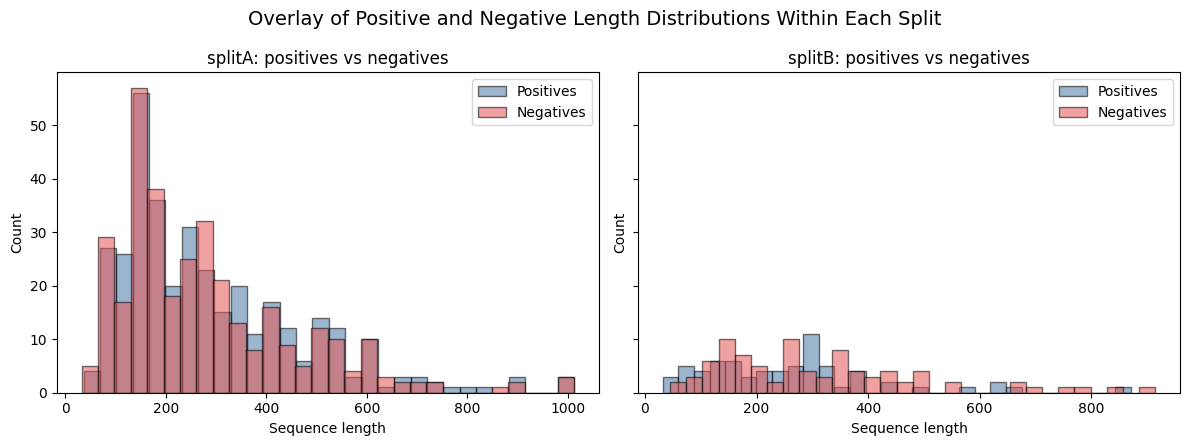

In [15]:
positives_split_a, positives_split_b, negatives_split_a, negatives_split_b, split_summary = split_combined_by_group(
    positives_for_split,
    negatives_matched,
    group_col="cluster_id",
    random_state=RANDOM_STATE,
    split_a_fraction=0.8,
)

print_step_summary("step_4e_split_positives", len(positives_for_split), len(positives_split_a) + len(positives_split_b))
print_step_summary("step_4e_split_negatives", len(negatives_matched), len(negatives_split_a) + len(negatives_split_b))
print(
    "step_4e_combined_group_split: "
    f"splitA_samples={int(split_summary['split_a_samples'])}, splitB_samples={int(split_summary['split_b_samples'])}, "
    f"splitA_positives={int(split_summary['split_a_positives'])}, splitA_negatives={int(split_summary['split_a_negatives'])}, "
    f"splitB_positives={int(split_summary['split_b_positives'])}, splitB_negatives={int(split_summary['split_b_negatives'])}, "
    f"splitA_positive_rate={split_summary['split_a_positive_rate']:.3f}, "
    f"splitB_positive_rate={split_summary['split_b_positive_rate']:.3f}, "
    f"splitA_groups={int(split_summary['split_a_groups'])}, splitB_groups={int(split_summary['split_b_groups'])}"
)

positives_split_a = positives_split_a.drop(columns=["cluster_id"], errors="ignore")
positives_split_b = positives_split_b.drop(columns=["cluster_id"], errors="ignore")
negatives_split_a = negatives_split_a.drop(columns=["cluster_id"], errors="ignore")
negatives_split_b = negatives_split_b.drop(columns=["cluster_id"], errors="ignore")

positives_split_a.to_csv(OUTPUT_DIR / "positives_splitA.csv", index=False)
positives_split_b.to_csv(OUTPUT_DIR / "positives_splitB.csv", index=False)
negatives_split_a.to_csv(OUTPUT_DIR / "negatives_splitA.csv", index=False)
negatives_split_b.to_csv(OUTPUT_DIR / "negatives_splitB.csv", index=False)

print(f"Saved: {OUTPUT_DIR / 'positives_splitA.csv'}")
print(f"Saved: {OUTPUT_DIR / 'positives_splitB.csv'}")
print(f"Saved: {OUTPUT_DIR / 'negatives_splitA.csv'}")
print(f"Saved: {OUTPUT_DIR / 'negatives_splitB.csv'}")

print(f"positives_splitA: {len(positives_split_a)} proteins")
print(f"positives_splitB: {len(positives_split_b)} proteins")
print(f"negatives_splitA: {len(negatives_split_a)} proteins")
print(f"negatives_splitB: {len(negatives_split_b)} proteins")

overlay_data = {
    "splitA": {
        "positives": positives_split_a["sequence"].astype(str).str.len(),
        "negatives": negatives_split_a["sequence"].astype(str).str.len(),
    },
    "splitB": {
        "positives": positives_split_b["sequence"].astype(str).str.len(),
        "negatives": negatives_split_b["sequence"].astype(str).str.len(),
    },
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (split_name, split_lengths) in zip(axes, overlay_data.items()):
    ax.hist(
        split_lengths["positives"],
        bins=30,
        alpha=0.55,
        color="#4c78a8",
        edgecolor="black",
        label="Positives",
    )
    ax.hist(
        split_lengths["negatives"],
        bins=30,
        alpha=0.55,
        color="#e45756",
        edgecolor="black",
        label="Negatives",
    )
    ax.set_title(f"{split_name}: positives vs negatives")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("Count")
    ax.legend()

fig.suptitle("Overlay of Positive and Negative Length Distributions Within Each Split", fontsize=14)
fig.tight_layout()
plt.show()


In [16]:
for path in [positives_fasta, negatives_fasta, negatives_nr_fasta]:
    delete_path_if_exists(path)
delete_path_if_exists(tmp_dir)

print("Temporary FASTA files and tmp_mmseqs directory removed.")

Temporary FASTA files and tmp_mmseqs directory removed.


In [17]:
df = pd.read_csv("/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positives_splitB.csv")

empty_mask = (
    df["epitope_start"].isna() |
    (df["epitope_start"].astype(str).str.strip() == "") |
    (df["epitope_start"].astype(str).str.lower() == "nan")
)

df[empty_mask][["accession", "epitope_start", "epitope_end"]].head()

,accession,epitope_start,epitope_end


In [18]:
df = pd.read_csv("/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/data/positives_splitA.csv")

empty_mask = (
    df["epitope_start"].isna() |
    (df["epitope_start"].astype(str).str.strip() == "") |
    (df["epitope_start"].astype(str).str.lower() == "nan")
)

df[empty_mask][["accession", "epitope_start", "epitope_end"]].head()

,accession,epitope_start,epitope_end


# Data Pipeline: deepalgpro_all → Final Train/Test Splits

## Overview
This table summarizes the full transformation pipeline from the initial FASTA dataset through IEDB annotation, filtering, clustering, contamination removal, and final split generation.

---

## File / Data Evolution

| Stage | File / Object | Type | Description |
|------|--------------|------|-------------|
| 1 | IEDB epitopes `t_cell_b_cell_MHC_II_epitopes.csv` | CSV | Raw epitope annotations (T/B-cell + MHC-II epitopes) |
| 2 | `positive_epitopes_full.csv` | CSV | IEDB epitopes + fetched full protein sequences (UniProt/NCBI) |
| 3 | `positives.csv` | CSV | Protein-level collapse of epitope intervals + epitope coverage computed |
| 4 | `positives.fasta` | FASTA | Filtered protein sequences (length ≤ 1022) |
| 5 | `positives_clusters` + `positives.fasta` | FASTA | MMseqs2 clustering on retained positives to assign homology groups for split-aware partitioning; all non-identical positives retained |
| 6 | UniProt TSV `uniprotkb_NOT_taxonomy_id_10239_NOT_tax_2026_04_08.tsv` | TSV | Raw negative protein dataset |
| 7 | `negatives.csv` | CSV | Standardized UniProt negatives |
| 8 | `negatives.fasta` | FASTA | Filtered negative sequences (length ≤ 1022) |
| 9 | `negatives_clusters` → `negatives_nr.fasta` | FASTA | MMseqs2 clustering → non-redundant representative negatives |
| 10 | `hits.tsv` | TSV | MMseqs2 cross-search: negatives vs positives (contamination detection) |
| 11 | `negatives_clean` | DataFrame | Negatives with contaminated sequences removed |
| 12 | `negatives_matched` | DataFrame | Length-matched negatives (1:1 distribution alignment) |
| 13 | `positives_splitA.csv` | CSV | Combined homology-aware split A (cluster-based, target 80%) |
| 14 | `positives_splitB.csv` | CSV | Frozen final test positives after combined split (target 20%) |
| 15 | `negatives_splitA.csv` | CSV | Combined homology-aware split A negatives |
| 16 | `negatives_splitB.csv` | CSV | Frozen final test negatives after combined split |

---

## Pipeline Flow (compact)

```text
IEDB annotation + sequence retrieval
        ↓
positives.csv (protein-level epitope collapse)
        ↓
positives.fasta ───────┐
                        ├── MMseqs2 clustering → positive cluster_id assignment on all retained positives
negatives.fasta ────────┘                        negatives_nr.fasta
                                                   ↓
                                     MMseqs2 cross-search (negatives_nr vs full positives)
                                                   ↓
                                          negatives_clean
                                                   ↓
                                    length-matched negatives (1:1)
                                                   ↓
                     combined homology-aware 80/20 splitting with approximate class balance
                                                   ↓
     ┌───────────────────────────────┬───────────────────────────────┐
     ↓                               ↓
positives_splitA.csv        positives_splitB.csv
negatives_splitA.csv        negatives_splitB.csv